<a href="https://colab.research.google.com/github/Surjith-ap/10_pin_ball_game/blob/main/Logistics_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

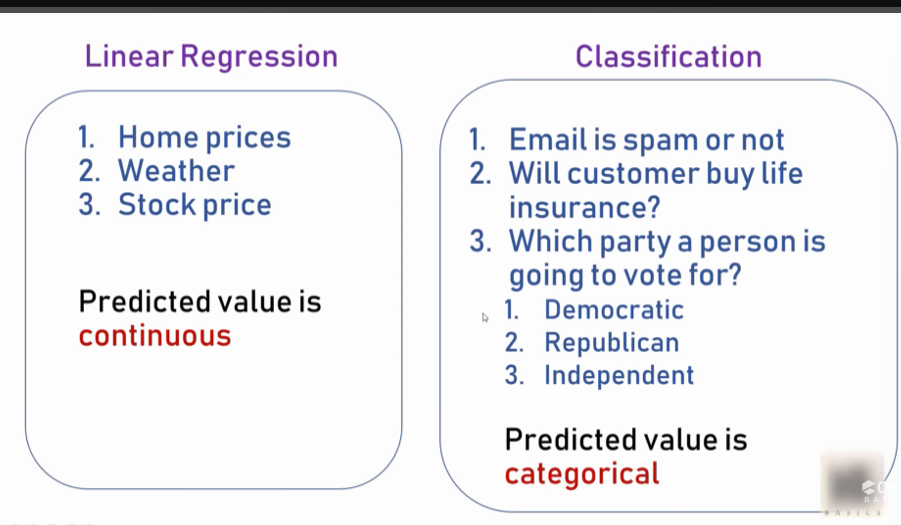Prediction on Categorical Values like yes or no, true or false


Classification types
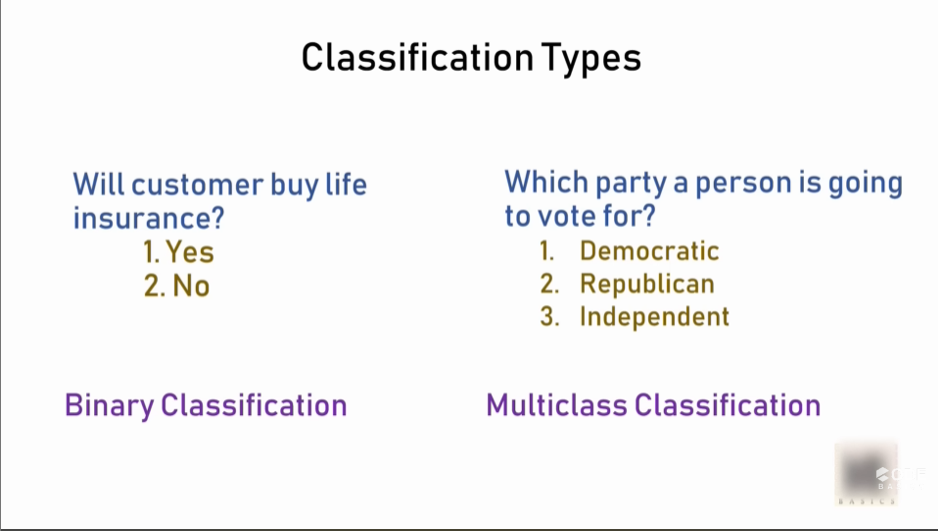

Sigmoid Function
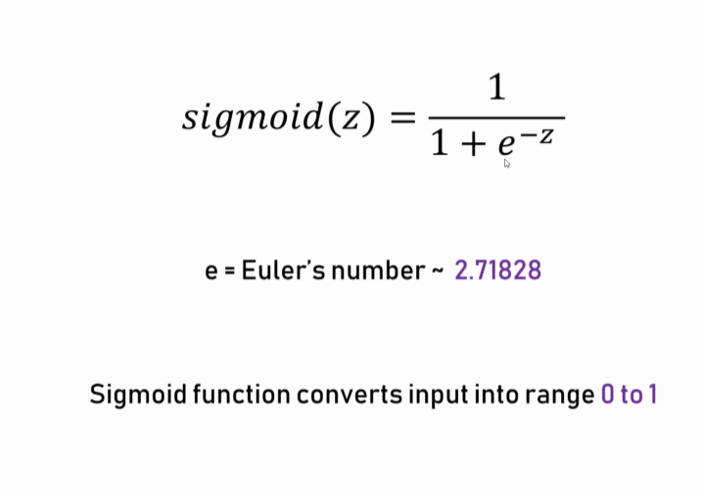

In [1]:
from google.colab import files

print("Please select the CSV to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# The uploaded file will be available in the current Colab runtime directory.

Please select the CSV to upload:


Saving insurance_data.csv to insurance_data.csv
User uploaded file "insurance_data.csv" with length 155 bytes


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline


In [3]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


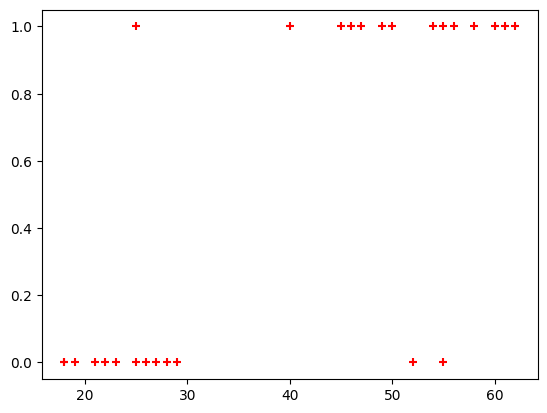

In [4]:
plt.scatter(df.age, df.bought_insurance,marker='+',color='red')

In [5]:
df.shape

(27, 2)

In [6]:
#split data set
from sklearn.model_selection import train_test_split


In [34]:
x_train, x_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, test_size=0.1)

In [35]:
x_test

,age
7,60
22,40
24,50


In [36]:
x_train

,age
17,58
8,62
5,56
25,54
13,29
11,28
2,47
20,21
10,18
0,22


In [37]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [38]:
model.fit(x_train, y_train)

LogisticRegression()

In [39]:
model.predict(x_test)

array([1, 0, 1])

In [40]:
model.score(x_test, y_test)

0.6666666666666666

In [41]:
model.predict_log_proba(x_test)

array([[-2.56334509, -0.08017651],
       [-0.64279909, -0.74616523],
       [-1.45553039, -0.26562917]])

EXERCISE
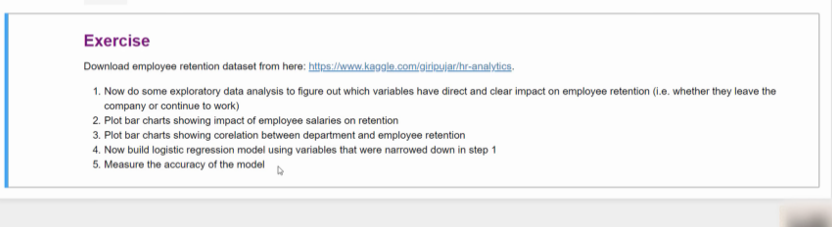

In [43]:
# code for manual upload
from google.colab import files

print("Please select the CSV to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# The uploaded file will be available in the current Colab runtime directory.

Please select the CSV to upload:


Saving HR_comma_sep.csv to HR_comma_sep.csv
User uploaded file "HR_comma_sep.csv" with length 551785 bytes


In [44]:
import pandas as pd
df = pd.read_csv('HR_comma_sep.csv')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [47]:
from matplotlib import pyplot as plt
%matplotlib inline

Data Exploration


In [48]:
left = df[df.left==1]
left.shape

(3571, 10)

In [49]:
retained = df[df.left==0]
retained.shape

(11428, 10)

From the data analysis so far we can conclude that we will use following variables as independant variables in our model
**Satisfaction Level**
**Average Monthly Hours**
**Promotion Last 5 Years**
**Salary**

In [52]:
subdf = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
subdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


Since salary is text we have to convert to numbers using dummy variables

In [53]:
salary_dummies = pd.get_dummies(subdf.salary,prefix="salary")
salary_dummies.head()

,salary_high,salary_low,salary_medium
0,False,True,False
1,False,False,True
2,False,False,True
3,False,True,False
4,False,True,False


In [54]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis='columns')
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [55]:
#remove salary column
df_with_dummies.drop('salary',axis='columns',inplace=True)
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [56]:
x = df_with_dummies
x.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [57]:
y = df.left

In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.3)

In [59]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [60]:
model.fit(x_train,y_train)

LogisticRegression()

In [61]:
model.predict(x_test)

array([0, 0, 0, ..., 1, 0, 0])

In [62]:
model.score(x_test,y_test)

0.776952380952381